In [113]:
import numpy as np
import math
import pandas as pd
import cv2
import os
import re
import tqdm
from scipy.io import loadmat
from pdf2image import convert_from_path

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from PIL import Image
import pytesseract

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import backend as K

#from utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam, SGD
from keras.layers import *

from keras.applications import MobileNetV2
from keras.applications import InceptionResNetV2

from keras.models import Model
from keras.models import model_from_json

from keras.models import load_model

In [136]:
## Find out all individual boxes for subsequent text extraction :

def all_boxes(pred_bom_id):
    
    boxes_list = []
    pred_bom = cv2.imread(pred_bom_id)
    pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

    ##thresholding the image to a binary image
    thresh,img_bin = cv2.threshold(pred_bom_gray,0,255,cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #inverting the image 
    img_bin_invert = 255-img_bin

    img_pil = Image.fromarray(img_bin_invert)
        
    display(img_pil) 
      
    # Length(width) of kernel as 100th of total width
    kernel_len = pred_bom_gray.shape[1]//100

    # Defining a vertical kernel to detect all vertical lines of image 
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_len))

    # Defining a horizontal kernel to detect all horizontal lines of image
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    #Use vertical kernel to detect and save the vertical lines in a jpg
    image_1 = cv2.erode(img_bin_invert, ver_kernel, iterations=3)
    vertical_lines = cv2.dilate(image_1, ver_kernel, iterations=3)

    #Use horizontal kernel to detect and save the horizontal lines in a jpg
    image_2 = cv2.erode(img_bin_invert, hor_kernel, iterations=3)
    horizontal_lines = cv2.dilate(image_2, hor_kernel, iterations=3)

    # Combine horizontal and vertical lines in a new third image, with both having same weight.
    img_vh = cv2.addWeighted(vertical_lines, 0.5, horizontal_lines, 0.5, 0.0)

    # A kernel of 2x2
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    # print('Final kernel = ', kernel)

    img_vh_d = cv2.dilate(img_vh, kernel, iterations=2)

    img_vh_d_pil = Image.fromarray(img_vh_d)
        
    display(img_vh_d_pil)
        
    # Defining the cell boxes

    contours, hierarchy = cv2.findContours(img_vh_d, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes = np.zeros((len(contours), 4))

    for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes[i, 0] = x
        boxes[i, 1] = y
        boxes[i, 2] = w
        boxes[i, 3] = h

    # print(len(boxes))
        
    boxes_list.append(boxes)
    
    return pred_bom, boxes_list      ## ## in format x, y, w, h


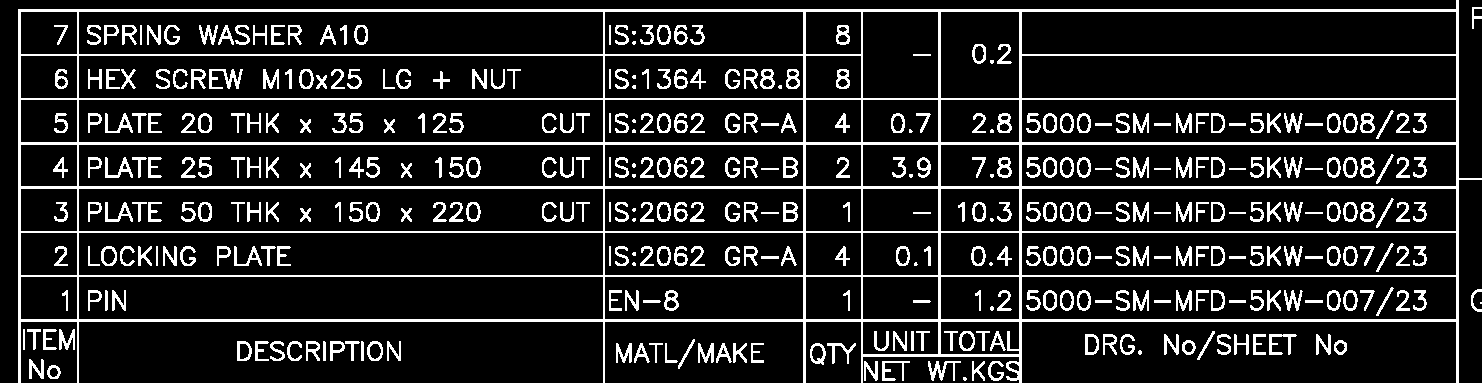

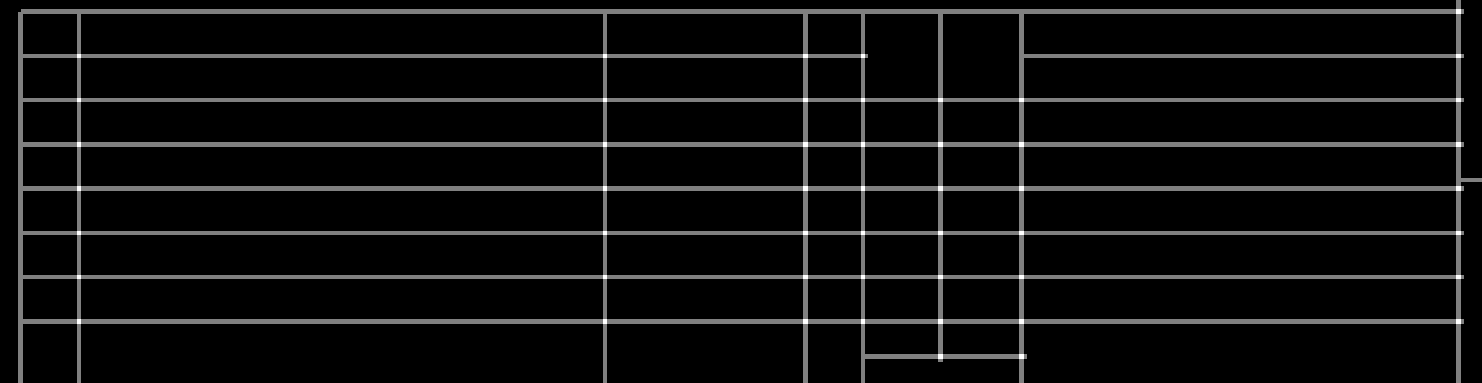

(383, 1482, 3)
[array([[  18.,    0., 1464.,  383.],
       [ 942.,  323.,   78.,   32.],
       [ 864.,  323.,   75.,   32.],
       [1023.,  278.,  434.,   42.],
       [ 942.,  278.,   78.,   42.],
       [ 864.,  278.,   75.,   42.],
       [ 807.,  278.,   55.,   42.],
       [ 606.,  278.,  198.,   42.],
       [  80.,  278.,  524.,   42.],
       [  22.,  278.,   56.,   42.],
       [1023.,  234.,  434.,   42.],
       [ 942.,  234.,   78.,   42.],
       [ 864.,  234.,   75.,   42.],
       [ 807.,  234.,   55.,   42.],
       [ 606.,  234.,  198.,   42.],
       [  80.,  234.,  524.,   42.],
       [  22.,  234.,   56.,   42.],
       [1023.,  190.,  434.,   42.],
       [ 942.,  190.,   78.,   42.],
       [ 864.,  190.,   75.,   42.],
       [ 807.,  190.,   55.,   42.],
       [ 606.,  190.,  198.,   42.],
       [  80.,  190.,  524.,   42.],
       [  22.,  190.,   56.,   42.],
       [1023.,  146.,  434.,   41.],
       [ 942.,  146.,   78.,   41.],
       [ 864.,  146., 

In [319]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
pred_bom, bom_boxes = all_boxes(pred_bom_id)
print(pred_bom.shape)
print(bom_boxes)

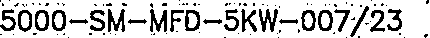

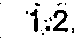

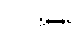

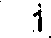

Identified bottom-left box with digits: 7 at (807, 278, 55, 42)


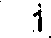

0 , 0 , 51 , 38
0 , 0 , 51 , 38


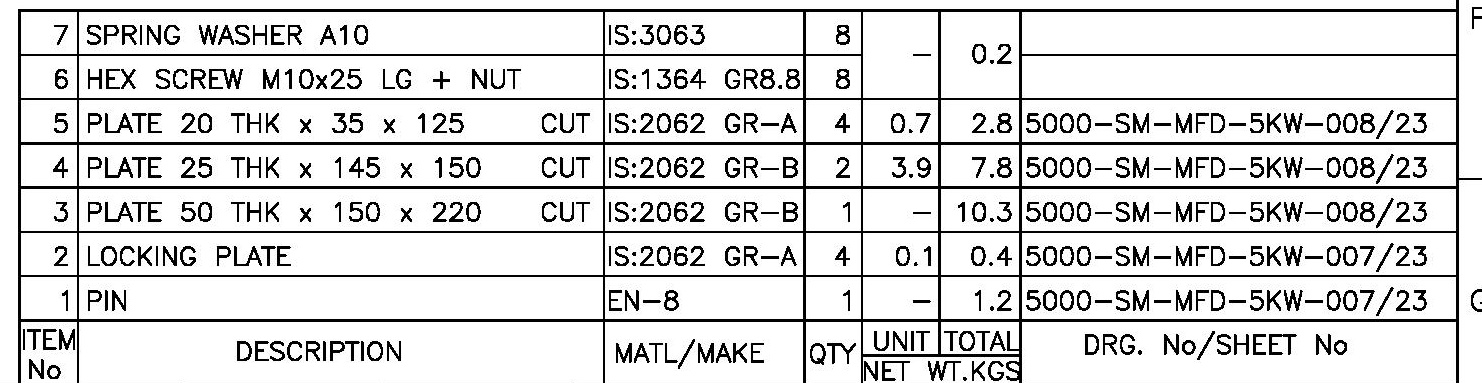

In [298]:
def find_bottom_left_digit_box(img, boxes):
    """
    Identify the bottom-most, left-most box containing only digits.
    Check if the digits are centered and shift if necessary.
    """
    # Step 1: Sort boxes by y (descending), then by x (ascending)
    sorted_boxes = sorted(boxes[0], key=lambda b: (b[1], b[0]), reverse=True)

    # Step 2: Find the first box containing only digits
    for box in sorted_boxes:
        x, y, w, h = map(int, box)  # Convert to int

        
        # Extract ROI
        roi_clr = img[y+2:y+2+h-4, x+2:x+2+w-4]
        roi = cv2.cvtColor(roi_clr, cv2.COLOR_BGR2GRAY)

        sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        roi_blur = cv2.GaussianBlur(roi_sharp, (5,5), 0)
        roi_thresh = cv2.adaptiveThreshold(roi_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
        kernel = np.ones((1, 1), np.uint8)
        img_denoised = cv2.morphologyEx(roi_thresh, cv2.MORPH_CLOSE, kernel)
        #roi_resized = cv2.resize(roi_thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

        custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
        text = pytesseract.image_to_string(img_denoised, config=custom_config).strip()

        img_pil = Image.fromarray(img_denoised)
        display(img_pil)
        """
   
        # Extract ROI
        roi = img[y:y+h, x:x+w]

        # Preprocess ROI for OCR
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi_thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

        # OCR with digits only
        custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789'
        text = pytesseract.image_to_string(roi_thresh, config=custom_config).strip()
        """

        # Check if the text contains only digits
        if text.isdigit():
            print(f"Identified bottom-left box with digits: {text} at ({x}, {y}, {w}, {h})")
            print('============================================================')

            img_pil = Image.fromarray(img_denoised)
            display(img_pil)
            
            # Step 3: Check if text is centered
            text_x, text_y, text_w, text_h = cv2.boundingRect(roi_thresh)
            text_x_1, text_y_1, text_w_1, text_h_1 = cv2.boundingRect(img_denoised)
            print(text_x, ',', text_y, ',', text_w, ',', text_h)
            print(text_x_1, ',', text_y_1, ',', text_w_1, ',', text_h_1)
            box_center_x = x + w // 2
            text_center_x = x + text_x + text_w // 2

            # Step 4: Shift text horizontally if not centered
            if abs(box_center_x - text_center_x) > 10:  # If misaligned by more than 5 pixels
                shift_x = box_center_x - text_center_x
                M = np.float32([[1, 0, shift_x], [0, 1, 0]])
                roi_shifted = cv2.warpAffine(roi_thresh, M, (w, h))

                # Replace original ROI with shifted one
                img[y:y+h, x:x+w] = cv2.cvtColor(roi_shifted, cv2.COLOR_GRAY2BGR)
                print(f"Shifted digits to center by {shift_x} pixels")

            return img  # Return modified image

    print("No suitable digit-only box found")
    return img  # Return original image if no change needed

# Process the image
modified_img = find_bottom_left_digit_box(pred_bom, bom_boxes)
img_pil = Image.fromarray(modified_img)
        
display(img_pil) 

text =  1


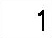

[[254 253 252 ... 254 254 252]
 [253 253 254 ... 255 255 253]
 [251 253 255 ... 254 255 253]
 ...
 [250 255 255 ... 254 250 253]
 [255 255 253 ... 255 255 247]
 [251 248 250 ... 253 246 253]]
text =  1

[[255 253 247 ... 253 254 246]
 [254 252 255 ... 255 255 250]
 [245 253 255 ... 254 255 249]
 ...
 [232 255 255 ... 255 234 255]
 [255 255 251 ... 255 255 219]
 [249 229 241 ... 254 214 255]]


In [299]:


x = 22 + 2
y = 278 + 2
w = 56 - 4
h = 42 - 4
pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
roi = pred_bom_gray[int(y):int(y+h), int(x):int(x+w)]  # Crop the region

#text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
text = pytesseract.image_to_string(roi, config='--psm 6 --oem 3').strip()  # OCR
print('text = ', text)

img_pil = Image.fromarray(roi)
        
display(img_pil)

print('=============================================================')
print(roi)
print('=============================================================')

"""
dilated_img = cv2.dilate(roi, np.ones((7,7), np.uint8), iterations=1)
bg_img = cv2.medianBlur(dilated_img, 21)
img_no_shadow = cv2.absdiff(roi, bg_img)
img_no_shadow = cv2.threshold(img_no_shadow, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
"""
sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
roi_blur = cv2.GaussianBlur(roi_sharp, (5,5), 0)
roi_thresh = cv2.adaptiveThreshold(roi_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
kernel = np.ones((1, 1), np.uint8)
img_denoised = cv2.morphologyEx(roi_thresh, cv2.MORPH_CLOSE, kernel)
#roi_resized = cv2.resize(roi_thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
text = pytesseract.image_to_string(roi_sharp, config=custom_config)

#text = pytesseract.image_to_string(img_denoised, lang="eng", config='--psm 6 --oem 3').strip()  # OCR
print('text = ', text)
print('=============================================================')
print(roi_sharp)





In [ ]:
x = 22
y = 278
w = 56
h = 42
pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
roi = pred_bom_gray[int(y):int(y+h), int(x):int(x+w)]  # Crop the region

#text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
text = pytesseract.image_to_string(roi, config='--psm 6 --oem 3').strip()  # OCR
print('text = ', text)

img_pil = Image.fromarray(roi)
        
display(img_pil)

print('=============================================================')


[[ 22.  13.  56.  42.]
 [ 22.  57.  56.  42.]
 [ 22. 101.  56.  42.]
 [ 22. 146.  56.  41.]
 [ 22. 190.  56.  42.]
 [ 22. 234.  56.  42.]
 [ 22. 278.  56.  42.]]
22 , 13 , 56 , 42
22 , 57 , 56 , 42
22 , 101 , 56 , 42
22 , 146 , 56 , 41
22 , 190 , 56 , 42
22 , 234 , 56 , 42
22 , 278 , 56 , 42
22 , 278 , 56 , 42


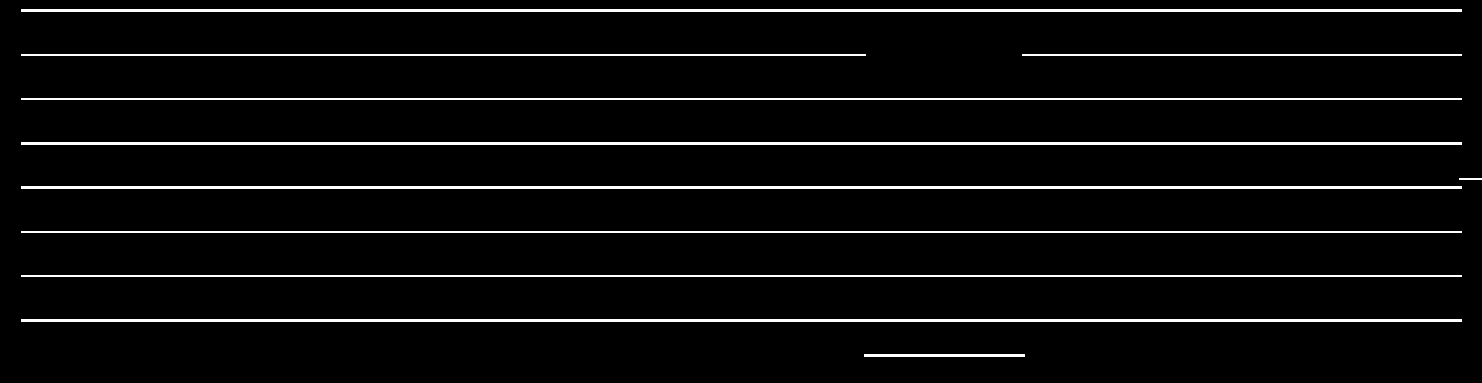

[(864, 354, 161, 3), (21, 319, 1441, 3), (21, 275, 1441, 2), (21, 231, 1441, 2), (21, 186, 1441, 3), (1459, 178, 23, 2), (21, 142, 1441, 3), (21, 98, 1441, 2), (1022, 54, 440, 2), (21, 54, 845, 2), (21, 9, 1441, 3)]
(21, 319, 1441, 3)
No longer horizontal line found. Drawing a new line at the bottom.


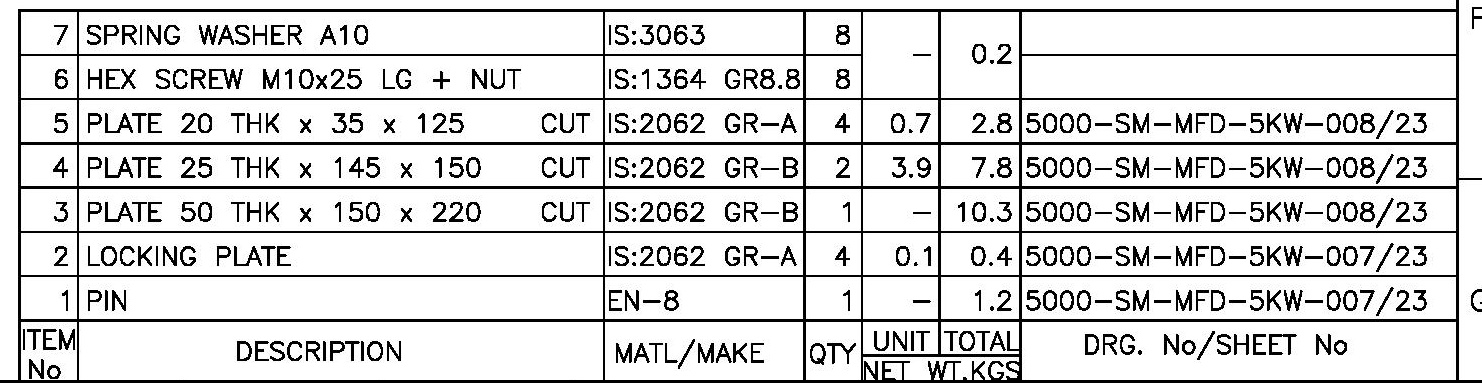

In [314]:
def find_bottom_left_one(bom_boxes, pred_bom):
    """
    Find the bottom-most left-most box containing '1'
    """
    boxes = sorted(bom_boxes[0], key=lambda b: (b[1], b[0]))  # Sort by y (bottom-first), then x (left-first)

    # Convert list of arrays into a NumPy array
    boxes_np = np.array(boxes)

    # Step 1: Find the minimum x-value, excluding y=0
    valid_boxes = boxes_np[boxes_np[:, 1] > 0]  # Keep only boxes with y > 0
    min_x = np.min(valid_boxes[:, 0])  # Get minimum x

    # Step 2: Get all boxes with this min_x value
    filtered_boxes = valid_boxes[valid_boxes[:, 0] == min_x]
    print(filtered_boxes)
    
    for box in filtered_boxes:
        
        x, y, w, h = map(int, box)  # Convert to int
        print(x, ',', y, ',', w, ',', h)
        print('=======================================================================')
        x_c = x + 2
        y_c = y + 2
        w_c = w - 4
        h_c = h - 4
        pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
        roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]  # Crop the region - increase of x,y and reduction of w,h is very 
        #important for text accuracy
        sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        
        #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        text = pytesseract.image_to_string(roi_sharp, config='--psm 6 --oem 3').strip()  # OCR
        if text == '1':
            return (x, y, w, h)  # Return coordinates of this box
    
    return None  # If not found

result = find_bottom_left_one(bom_boxes, pred_bom)

if result:  # Check if function returned a valid box
    x, y, w, h = result
    print(x, ',', y, ',', w, ',', h)
else:
    print("No suitable box found")

print('=======================================================================')


def draw_horizontal_line_if_needed(pred_bom, x, y, w, h):
    """
    Check if the longest horizontal line below the given box has another such line below it.
    If not, draw a new horizontal line at the bottom of the image.

    :param image_path: Path to the input image
    :param x, y, w, h: Coordinates of the bottom-most-left-most box containing "1"
    :return: Modified image
    """
    
    # Convert image to grayscale
    image = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
    
    # Apply binary threshold
    _, img_bin = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Invert image (white background, black lines)
    img_bin_inv = 255 - img_bin
    
    # Define horizontal kernel
    kernel_len = image.shape[1] // 100
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    # Extract horizontal lines
    hor_lines = cv2.erode(img_bin_inv, hor_kernel, iterations=3)
    hor_lines = cv2.dilate(hor_lines, hor_kernel, iterations=3)

    img_pil = Image.fromarray(hor_lines)
    display(img_pil)
    print('=============================================================')
    # Find contours of horizontal lines
    contours, _ = cv2.findContours(hor_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert contours to (x, y, w, h) format
    hor_lines_list = [cv2.boundingRect(cnt) for cnt in contours]

    # Sort lines based on the y-coordinate (bottom-most first)
    hor_lines_list = sorted(hor_lines_list, key=lambda x: x[1], reverse=True)
    print(hor_lines_list)
    print('=============================================================')
    
    """
    # Find the longest horizontal line below this box
    #longest_line = max((line for line in hor_lines_list if line[1] > box_bottom_y), key=lambda x: x[2], default=None)
    longest_line = max((line for line in hor_lines_list if line[1] > y), key=lambda x: x[2], default=None)
    print(longest_line)
    print('=============================================================')
    """

    # Find the longest horizontal line immediately below this box
    # Find the smallest y-value that is greater than 202
    filtered_values = [item for item in hor_lines_list if item[1] > y]

    # Get the entry with the minimum y-value
    if filtered_values:
        longest_line = min(filtered_values, key=lambda x: x[1]) 
    print(longest_line)
    print('=============================================================')
    
    """
    # Find the number of longest horizontal line below the identified box :
    long_line_count = sum(1 for _, y_value, _, _ in hor_lines_list if y_value > y)
    print(long_line_count)
    print('=============================================================')
    
    if long_line_count >1:
        print('no need to draw a new line')
    else:
        #img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        longest_line = max((line for line in hor_lines_list if line[1] > y), key=lambda x: x[2], default=None)
        _, y_longest, w_longest, _ = longest_line
        img_height, img_width = pred_bom.shape[:2]
        y_new_line = img_height - 1  # one pixel above the bottom edge
        cv2.line(pred_bom, (0, y_new_line), (w_longest, y_new_line), (0, 0, 0), 2)
        
        return pred_bom
    
    """
    
    if longest_line:
        x_longest, y_longest, w_longest, _ = longest_line

        # Check if another horizontal line exists below it with equal or greater width
        for x_line, y_line, w_line, h_line in hor_lines_list:
            if y_line > y_longest and w_line >= w_longest:
                print("A longer or equal horizontal line exists below. No need to draw a new line.")
                return pred_bom  # No need to draw a new line

        # If no such line exists, draw a new horizontal line
        print("No longer horizontal line found. Drawing a new line at the bottom.")
        # img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        img_height, img_width = pred_bom.shape[:2]
        y_new_line = img_height - 2 # two pixel above the bottom edge
        cv2.line(pred_bom, (0, y_new_line), (img_width, y_new_line), (0, 0, 0), 2)
        
        return pred_bom

    else:
        print("No horizontal line found below the given box.")
        return pred_bom  # No modifications needed
    
# Run function and get modified image
pred_bom_corrected = draw_horizontal_line_if_needed(pred_bom, x, y, w, h)

img_pil = Image.fromarray(pred_bom_corrected)
display(img_pil)


In [315]:
pred_bom, bom_boxes = all_boxes(pred_bom_corrected)

TypeError: Can't convert object of type 'numpy.ndarray' to 'str' for 'filename'

In [120]:
def header_and_item(pred_bom_id):
    pred_bom, bom_boxes = all_boxes(pred_bom_id)

    for i in range(len(bom_boxes)):
        if i == 0:
            col_count_list = []
            header_boxes_list = []
            bom_boxes_list = []
            item_index_width_list = []

        boxes_1 = bom_boxes[i][1:]  # Removing the line of full box (0th row)
        
        # Find number of columns: max occurrence of any y-value
        y_list = boxes_1[:, 1].tolist()  # Extract y values
        col_count_array = np.bincount(y_list)  # Count occurrences of each y-value
        col_count = col_count_array.max()  # Max number of occurrences of any one y-value

        print('No. of columns = ', col_count)
        
        # Default initialization (to avoid UnboundLocalError)
        y_header_row = None
        item_index_width = None
        bom_boxes_1 = boxes_1  # Default: Keep all data in BOM
        
        # Identify the header row (always at the bottom)
        y_bmrm_cell = boxes_1[0][1]  # y value of 1st bottom-most cell
        num_col = y_list.count(y_bmrm_cell)  # Count occurrences of this y value

        if num_col == col_count:
            y_header_row = y_bmrm_cell
            item_index_width = boxes_1[col_count-1, 2]  # Width of the 'Item No.' column
            bom_boxes_1 = boxes_1[1:]  # Remove 1st header row for BOM processing
        
        else:
            if len(boxes_1) > 1:  # Ensure there is a next row before accessing it
                y_next_cell = boxes_1[1][1]
                num_col = y_list.count(y_next_cell)

                if num_col == col_count:
                    y_header_row = y_next_cell
                    item_index_width = boxes_1[col_count, 2]
                    bom_boxes_1 = boxes_1[2:]  # Remove first two rows for BOM processing
        
        # Ensure y_header_row is assigned before proceeding
        if y_header_row is None:
            raise ValueError("Failed to detect header row. Check image processing.")

        header_boxes = boxes_1[boxes_1[:, 1] == y_header_row]
        bom_boxes = bom_boxes_1[bom_boxes_1[:, 1] != y_header_row]
        
        col_count_list.append(col_count)
        item_index_width_list.append(item_index_width)
        header_boxes_list.append(header_boxes)
        bom_boxes_list.append(bom_boxes)
    
    return pred_bom, col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list  # all boxes in x, y, w, h format


In [115]:
## Take out header boxes and all other box info for all items separately :

def header_and_item(pred_bom_id):
    
    pred_bom, bom_boxes = all_boxes(pred_bom_id)

    for i in range(len(bom_boxes)):

        if i == 0:
            col_count_list = []
            header_boxes_list = []
            bom_boxes_list = []
            item_index_width_list = []

        boxes_1 = bom_boxes[i][1:]   ## removing the line of full box i.e. removing 0th row
        
        ## Find number of columns i.e. max occurance of any y value :

        y_list = boxes_1[:, 1].tolist()   ## since boxes are in x,y,w,h format (output from cv2.boundingRect)

        col_count_array = np.bincount(y_list)  ## no. of occurances of each y-value
        col_count = col_count_array.max()  ## max. no. of occurances of any one y-value

        print('No. of columns = ', col_count)
        

        # Now fid the Header row.

        # In drawings, header row is always at the bottom.
        # Output of cv2.boundingRect always starts with the box of complete BOM
        # After this 1st row, the output starts with the bottom_most_right_most (in this order) box details.

        # So, y value of boxes[1] is the bottom_most-right_most (in this order) cell y value.

        y_bmrm_cell = boxes_1[0][1]  # y value of 1st bottom most cell

        # If occurances of this y value of 1st bottom most cell = number of columns, then this is the y value of Header Row

        num_col = y_list.count(y_bmrm_cell)   ## no. of occurances of y_bmrm_cell value 

        if num_col == col_count:
    
            y_header_row = y_bmrm_cell
            item_index_width = boxes_1[col_count-1, 2]  # This is the width of the 1st column i.e. 'Item No.' column
            bom_boxes_1 = boxes_1[1:]   ## remove 1st header row for bom consideration
    
        else:
        
            y_next_cell = boxes_1[1][1]

            num_col = y_list.count(y_next_cell)

            if num_col == col_count:
    
                y_header_row = y_next_cell
                item_index_width = boxes_1[col_count, 2]
                bom_boxes_1 = boxes_1[2:]    ## remove 1st 2 rows for bom consideration

        header_boxes = boxes_1[boxes_1[:, 1] == y_header_row]
    
        bom_boxes = bom_boxes_1[bom_boxes_1[:, 1] != y_header_row]
        
        col_count_list.append(col_count)
        item_index_width_list.append(item_index_width)
        header_boxes_list.append(header_boxes)
        bom_boxes_list.append(bom_boxes)
    
    return pred_bom, col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list  ## all boxes in x, y, w, h format


In [116]:
# Remove grid lines from bom image:

def remove_grid_lines(image_path):    
    # Read the image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Edge detection to find vertical lines
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=100, maxLineGap=10)

    # Initialize extreme left and right x-coordinates
    leftmost_x = image.shape[1]  # Initialize with max width
    rightmost_x = 0  # Initialize with min width

    if lines is not None:  # Ensure lines are detected
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(x1 - x2) < 10:  # Check if the line is vertical
                leftmost_x = min(leftmost_x, x1)
                rightmost_x = max(rightmost_x, x1)

    # Ensure valid margins
    left_margin = leftmost_x if leftmost_x != image.shape[1] else 0
    right_margin = image.shape[1] - rightmost_x if rightmost_x != 0 else 0

    # Crop the image within detected leftmost and rightmost boundaries
    cropped_image = image[:, leftmost_x:rightmost_x]

    #===============================================================
    # Now remove all gridlines:
    cropped_image_gray = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(cropped_image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 2)
    
    # Define horizontal and vertical kernels for morphological operations
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    
    # Detect horizontal and vertical lines
    horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    vertical_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel, iterations=2)
    
    # Combine the detected lines
    grid_lines = cv2.add(horizontal_lines, vertical_lines)
    
    # Inpaint the grid lines to remove them
    inpainted_image = cv2.inpaint(cropped_image, grid_lines, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    return inpainted_image, left_margin


In [118]:
def bom_df_rev(pred_bom_id):
    
    # Extract header and item details
    pred_bom, col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list = header_and_item(pred_bom_id)
    gridless_bom_image, left_margin = remove_grid_lines(pred_bom_id)

    # Ensure we have header boxes
    if not header_boxes_list or len(header_boxes_list) == 0:
        print("Error: No header boxes found!")
        return None, None

    # Extract header column widths
    width_list = header_boxes_list[0][:, 2]  
    x_list = header_boxes_list[0][:, 0]
    print('width list = ', width_list)
    # Find the frequency of column widths
    width_frequency = np.unique(width_list, return_counts=True)[1]  
    print('Width Frequency:', width_frequency)

    # Get all column widths from BOM items
    all_width_list = bom_boxes_list[0][:, 2].tolist()
    row_count_array = np.bincount(all_width_list)  
    row_count_apparent = row_count_array.max()
    
    # Estimate row count
    row_count = row_count_apparent // np.max(width_frequency)
    print('Estimated Row Count:', row_count)

    # Extract header text
    header_text = []
    for box in header_boxes_list[0]:  
        x, y, w, h = map(int, box)  # Convert to integers
        header_crop = pred_bom[y:y+h, x:x+w]

        # Convert to grayscale & threshold
        header_gray = cv2.cvtColor(header_crop, cv2.COLOR_BGR2GRAY)
        _, header_bin = cv2.threshold(header_gray, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

        # OCR text extraction
        text = pytesseract.image_to_string(header_bin, config='--psm 6 --oem 3').strip()
        header_text.append(text)

    header_text.append('img_id')  
    serialised_header_text = header_text[::-1]  # Reverse order

    # Extract BOM items
    bom_text = []
    for i, bom_boxes in enumerate(bom_boxes_list):
        y_unique = np.unique(bom_boxes[:, 1])[::-1]  # Reverse order

        for j in y_unique:
            bom_sub_text = []
            aa = np.ones((col_count_list[0], 4))  

            bb = bom_boxes[bom_boxes[:, 1] == j]  # Select only rows with matching Y

            for k in range(len(width_list)):
                for l in range(len(bb)):
                    if (bb[l][2] + bb[l][0]) == (width_list[k] + x_list[k]):
                        aa[k, :] = bb[l, :]

            for k in range(len(aa)):
                x, y, w, h = map(int, aa[k])
                if k == 0:
                    cell_crop_image = gridless_bom_image[y:y+h, x:x+w-int(left_margin)]
                else:
                    cell_crop_image = gridless_bom_image[y:y+h, x-int(left_margin):x+w-int(left_margin)]  

                # Convert to grayscale & threshold
                #--------------------------------------------------------
                """
                cell_crop_height, cell_crop_width = cell_crop_image.shape[:2]
                new_width = int(cell_crop_width * 2)
                new_height = int(cell_crop_height * 2)
                cell_crop_image_resized = cv2.resize(cell_crop_image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)
                """
                #--------------------------------------------------------

                #cell_gray = cv2.cvtColor(cell_crop_image_resized, cv2.COLOR_BGR2GRAY)
                cell_gray = cv2.cvtColor(cell_crop_image, cv2.COLOR_BGR2GRAY)

                _, cell_bin = cv2.threshold(cell_gray, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
                text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 1 -c tessedit_char_whitelist=0123456789').strip()
                bom_sub_text.append(text)

            bom_id = ((pred_bom_id.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            bom_sub_text.append(bom_id)  # Append image ID
            bom_text.append(bom_sub_text[::-1])  # Reverse order

    # Convert to DataFrame
    df = pd.DataFrame(bom_text, columns=serialised_header_text)
    return df, bom_text, bom_sub_text


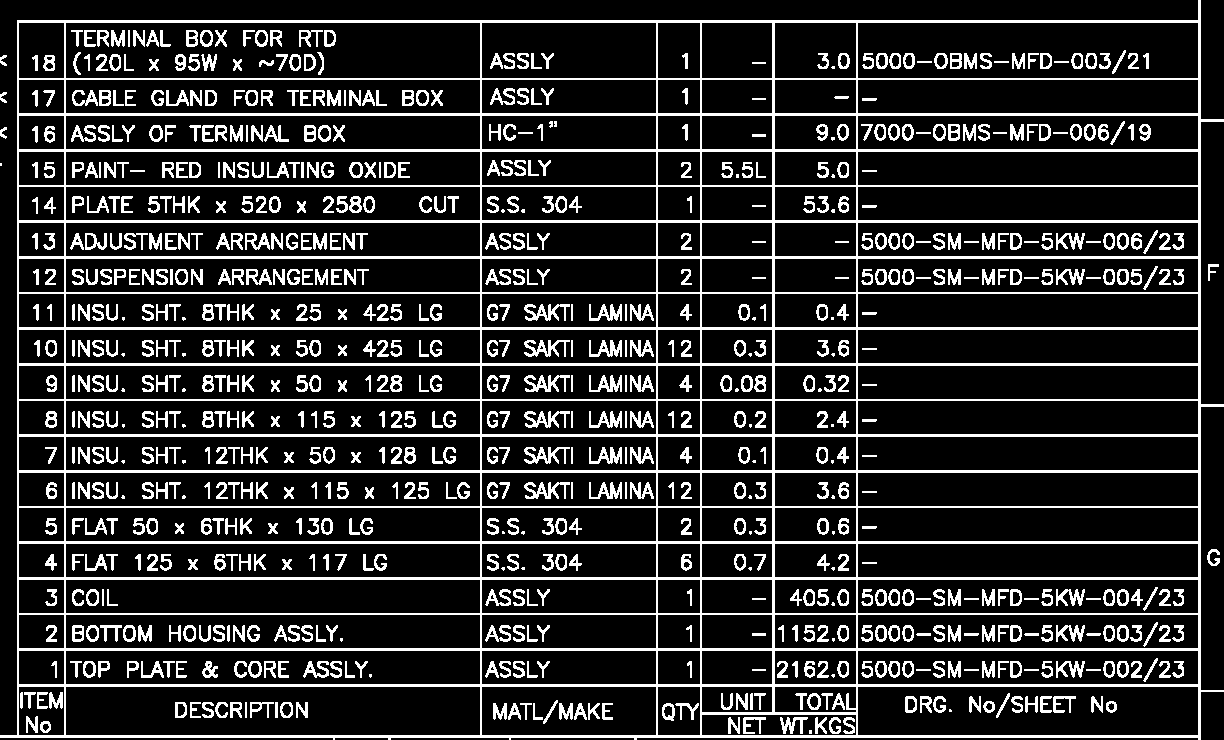

No. of columns =  7
width list =  [340.  81.  70.  42. 174. 414.  45.]
Width Frequency: [1 1 1 1 1 1 1]
Estimated Row Count: 18


In [122]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [123]:
df.head(20)

,img_id,TEM\nNo,DESCRIPTION,MATL/MAKE,ary,UNIT,TOTAL,DRG. No/SHEET No
0,SM-MFD-5KW-001-23,1,TOP PLATE & CORE ASSLY.,ASSLY,1,,2162.0,000—SM—MFD—5KW-002/23
1,SM-MFD-5KW-001-23,2,BOTTOM HOUSING ASSLY.,ASSLY,1,,1152.0,000—SM—MFD—5KW-003/23
2,SM-MFD-5KW-001-23,3,coIL,ASSLY,1,,405.0,000—SM—MFD—5KW-004/23
3,SM-MFD-5KW-001-23,4,FLAT 125 x 8THK x 117 LG,$.S. 304,6,0.7,4.2,
4,SM-MFD-5KW-001-23,5,FLAT 50 x 6THK x 130 LG,S.S. 304,2,0.3,0.6,
5,SM-MFD-5KW-001-23,6,INSU. SHT. 12THK x 115 x 125 LG,G7 SAKTI LAMINA,12,0.3,3.6,
6,SM-MFD-5KW-001-23,7,INSU. SHT. 12THK x 50 x 128 LG,G7 SAKTI LAMINA,4,0.1,0.4,
7,SM-MFD-5KW-001-23,8,INSU. SHT. 8THK x 115 x 125 LG,G7 SAKTI LAMINA,12,0.2,2.4,
8,SM-MFD-5KW-001-23,9,INSU. SHT. 8THK x 50 x 128 LG,G7 SAKTI LAMINA,4,0.08,0.32,
9,SM-MFD-5KW-001-23,10,INSU. SHT. 8THK x 50 x 425 LG,G7 SAKTI LAMINA,12,0.3,3.6,


In [90]:
# Save DataFrame to Excel
excel_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/first_success.xlsx"  # Change the path if needed
df.to_excel(excel_path, index=False, engine='openpyxl')


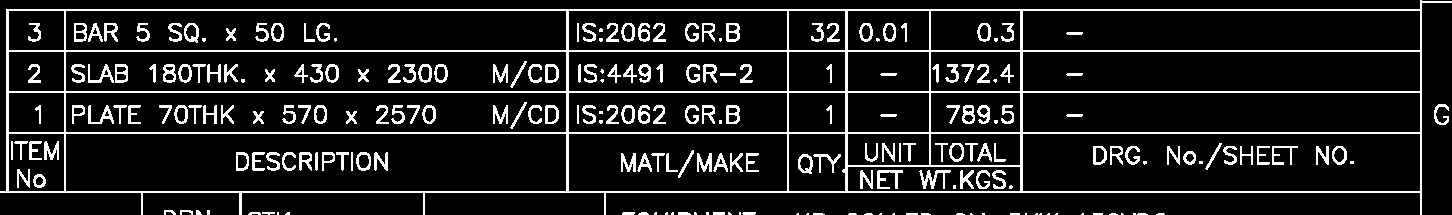

No. of columns =  7
width list =  [397.  89.  81.  56. 218. 500.  55.]
Width Frequency: [1 1 1 1 1 1 1]
Estimated Row Count: 3


In [126]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-002-23.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [127]:
df.head(5)

,img_id,ITEM\nNo,DESCRIPTION,MATL/MAKE,ary.,UNIT,TOTAL,DRG. No./SHEET NO.
0,SM-MFD-5KW-002-23,1,PLATE 7OTHK x 570 x 2570 M/CD,IS:2062 GR.B,1,,789.5,
1,SM-MFD-5KW-002-23,2,SLAB 180THK. x 430 x 2300 M/CD,1S:4491 GR-2,1,,1372.4,
2,SM-MFD-5KW-002-23,3,BAR 5 SQ. x 50 LG.,IS:2062 GR.B,32,0.01,0.35,


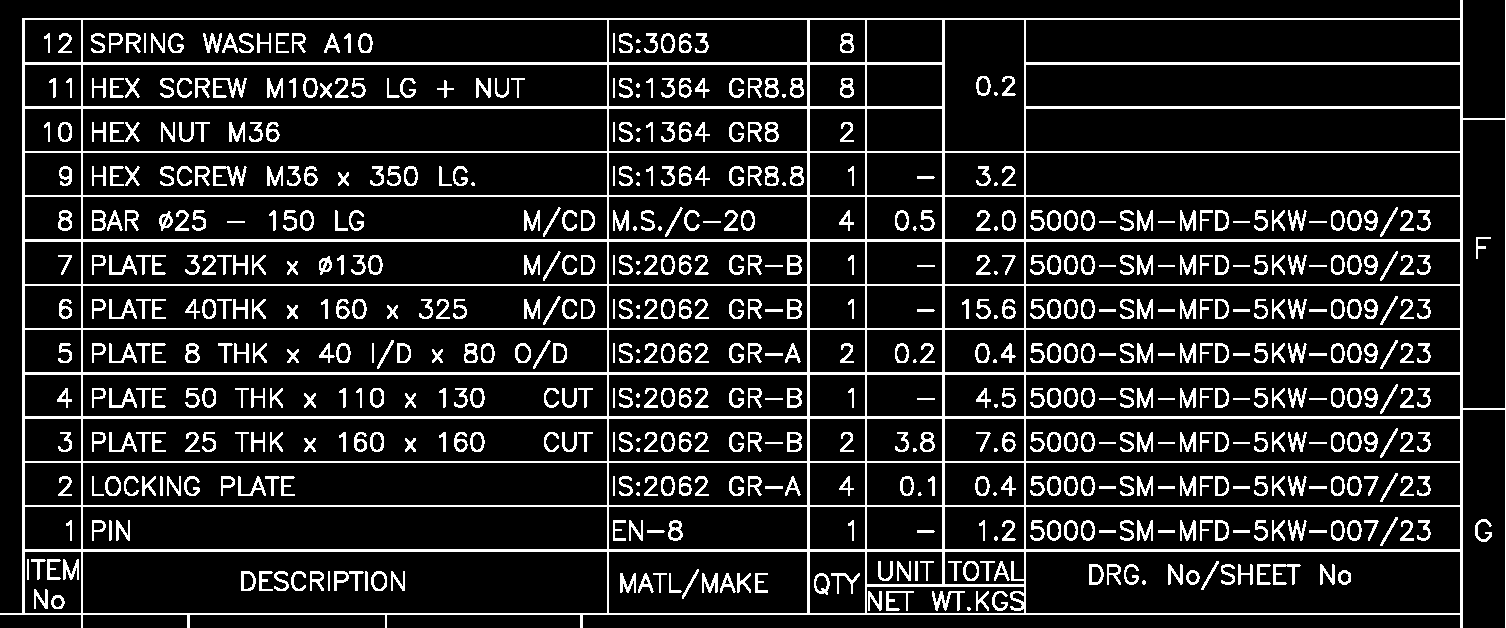

No. of columns =  7
width list =  [434.  79.  75.  55. 198. 524.  56.]
Width Frequency: [1 1 1 1 1 1 1]
Estimated Row Count: 12


In [129]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-006-23.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [130]:
df.head(20)

,img_id,ITEM\nNo,DESCRIPTION,MATL/MAKE,ory,UNIT,TOTAL,DRG. No/SHEET No
0,SM-MFD-5KW-006-23,1,PIN,EN-8,1,,1.2,000-SM—MFD—5KW-007/23
1,SM-MFD-5KW-006-23,2,LOCKING PLATE,IS:2062 GR-A,4,0.1,0.4,D00-SM—MFD—5KW-—007/23
2,SM-MFD-5KW-006-23,3,PLATE 25 THK x 160 x 160 CUT,IS:2062 GR-B,2,3.8,7.6,000—SM—MFD—5KW-009/23
3,SM-MFD-5KW-006-23,4,PLATE 50 THK x 110 x 130 CUT,IS:2062 GR-B,1,,4.5,000—SM—MFD—5KW-—009/23
4,SM-MFD-5KW-006-23,5,PLATE 8 THK x 40 I/D x 80 O/D,IS:2062 GR-A,2,0.2,0.4,000-SM—MFD—5KW-—009/23
5,SM-MFD-5KW-006-23,6,PLATE 40THK x 160 x 325 M/CD,IS:2062 GR-B,1,,15.6,D00-SM—MFD—5SKW-—009/23
6,SM-MFD-5KW-006-23,7,PLATE 32THK x #130 M/CD,IS:2062 GR-B,1,,2.7,000—SM—MFD—5KW-—009/23
7,SM-MFD-5KW-006-23,8,BAR #25 — 150 LG M/CD,M.S./C—20,4,0.5,2.0,000-—SM—MFD—5KW-—009/23
8,SM-MFD-5KW-006-23,9,HEX SCREW M36 x 350 LG.,IS:1364 GR8.8,1,,3.2,oo
9,SM-MFD-5KW-006-23,,,,,,,


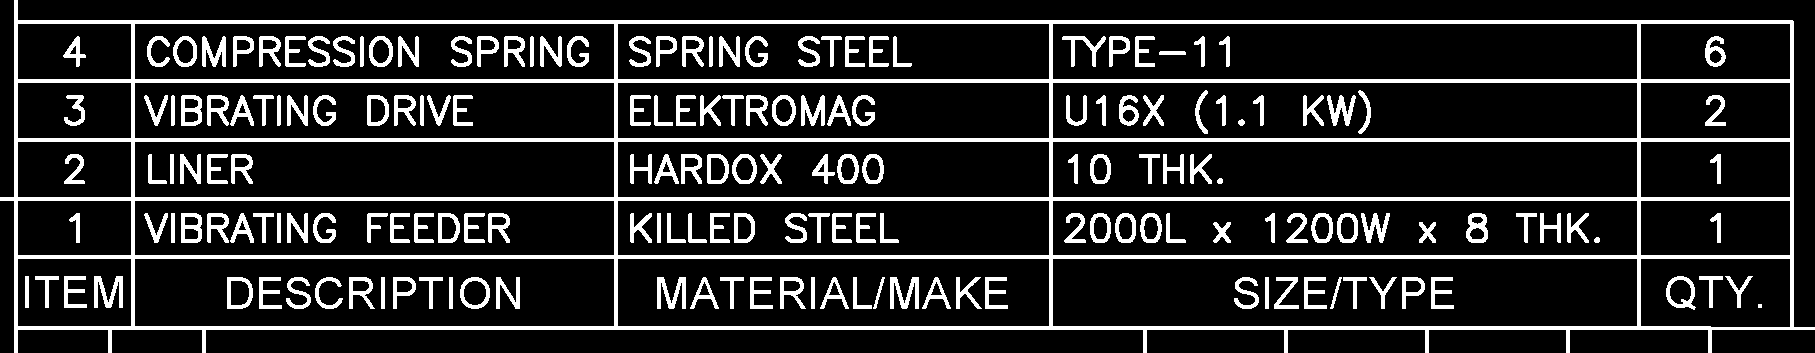

No. of columns =  5
width list =  [149. 584. 431. 479. 113.]
Width Frequency: [1 1 1 1 1]
Estimated Row Count: 4


In [124]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [125]:
df.head(20)

,img_id,ITEM,DESCRIPTION,MATERIAL/MAKE,SIZE/TYPE,QTY.
0,1023,4,VIBRATING FEEDER,KILLED STEEL,2000L x 1200W x 8 THK.,4
1,1023,2,LINER,HARDOX 400,10 THK.,4
2,1023,3,VIBRATING DRIVE,ELEKTROMAG,U16X (1.1 KW),2
3,1023,4,COMPRESSION SPRING,SPRING STEEL,TYPE-11,6


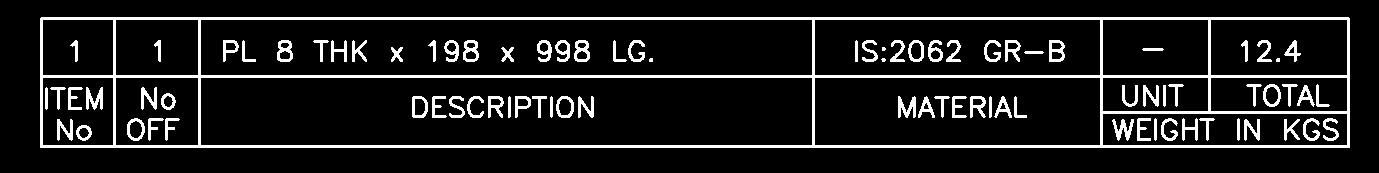

No. of columns =  6
width list =  [136. 105. 285. 611.  82.  70.]
Width Frequency: [1 1 1 1 1 1]
Estimated Row Count: 1


In [131]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [132]:
df.head()

,img_id,ITEM\nNo,No\nOFF,DESCRIPTION,MATERIAL,UNIT,TOTAL
0,1039,1,1,PL 8 THK x 198 x 998 LG.,IS:2062 GR-B,,2.4


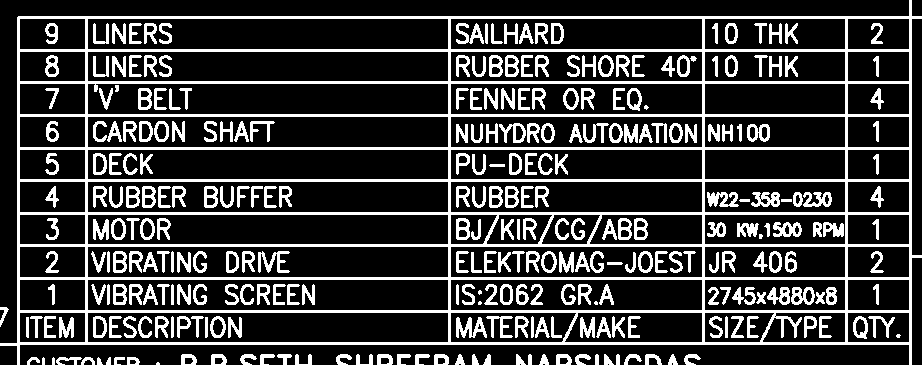

No. of columns =  5
width list =  [ 61. 140. 251. 360.  65.]
Width Frequency: [1 1 1 1 1]
Estimated Row Count: 9


In [133]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1111.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [134]:
df.head(20)

,img_id,ITEM,DESCRIPTION,MATERIAL/ MAKE,SIZE/TYPE,QTY.
0,1111,,,,,
1,1111,1,VIBRATING SCREEN,IS:2062 GRA,2745x4880x8,1
2,1111,2,VIBRATING DRIVE,ELEKTROMAG—JOEST,JR 406,2
3,1111,3,MOTOR,BJ/KIR/CG/ABB,"30 KW,1500 RPM",1
4,1111,4,RUBBER BUFFER,RUBBER,W22-358-0230,4
5,1111,5,DECK,PU-DECK,,1
6,1111,,,,,
7,1111,6,CARDON SHAFT,NUHYDRO AUTOMATION,NH100,1
8,1111,7,V BELT,FENNER OR EQ.,aa |,4
9,1111,8,LINERS,RUBBER SHORE 40°,10 THK,1


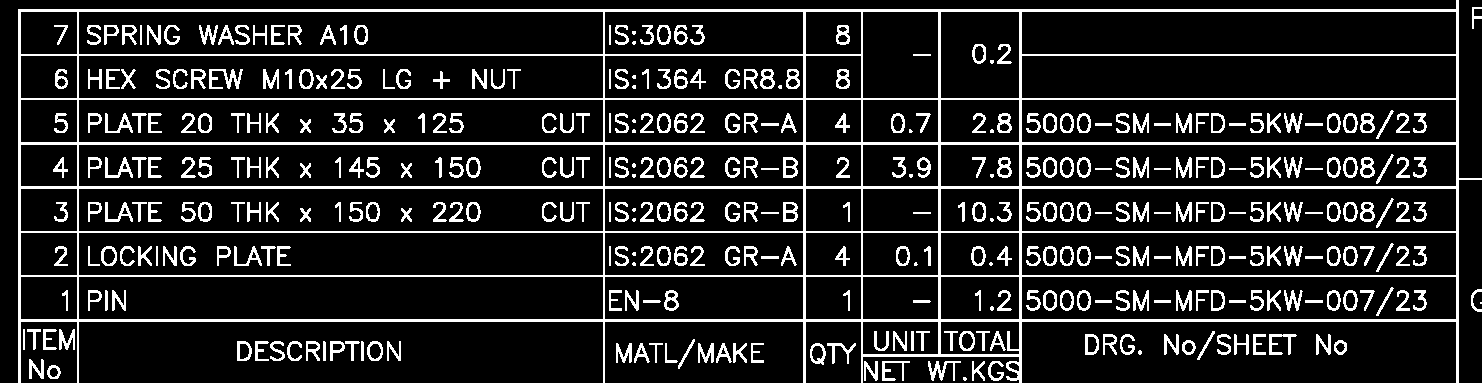

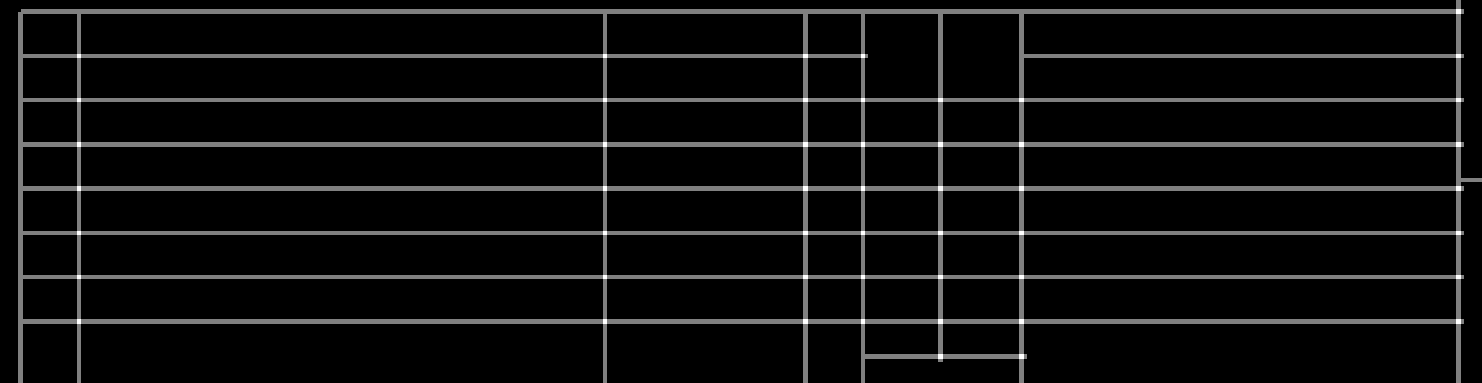

No. of columns =  7


ValueError: Failed to detect header row. Check image processing.

In [137]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [ ]:
# extract table of materials from the engineering drawing file
# the output is wrong
# can you extract all the items with serial numbers
# there are 18 line items in the main image
# Other than Sl. Nos., there are 6 columns. we have got info for only 3 columns

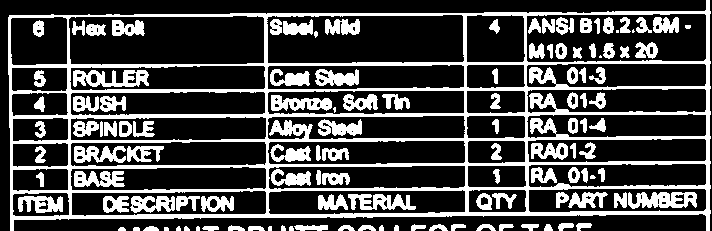

No. of columns =  2
width list =  [56. 28.]
Width Frequency: [1 1]
Estimated Row Count: 6


In [102]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/Screenshot_1_2025.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

In [105]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/Screenshot_1_2025.jpg"
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)

AttributeError: 'tuple' object has no attribute '__array_interface__'

In [107]:
def merge_csv_files(input_folder, output_folder, output_file):
    # Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # List all CSV files in the input folder
    csv_files = [f for f in os.listdir(input_folder) if f.endswith('.csv')]
    
    dataframes = []
    for file in csv_files:
        file_path = os.path.join(input_folder, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)
    
    # Merge all dataframes
    merged_df = pd.concat(dataframes, ignore_index=True)
    
    # Standardize column order based on the first file
    standard_columns = list(dataframes[0].columns)
    merged_df = merged_df[standard_columns]
    
    # Save to an Excel file
    output_path = os.path.join(output_folder, output_file)
    merged_df.to_excel(output_path, index=False)
    
    print(f'Merged file saved at: {output_path}')

# Define paths
input_folder = "/Users/subrata/workstation/jupyterFiles/extracted_table"
output_folder = "/Users/subrata/workstation/jupyterFiles/merged_output"
output_file = "merged_data.xlsx"

# Run the function
merge_csv_files(input_folder, output_folder, output_file)


Merged file saved at: /Users/subrata/workstation/jupyterFiles/merged_output/merged_data.xlsx


In [109]:
# Define input and output folder paths
input_folder = "/Users/subrata/workstation/jupyterFiles/extracted_table"
output_folder = "/Users/subrata/workstation/jupyterFiles/merged_output"

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Get list of all files in the input folder
all_files = os.listdir(input_folder)

# Filter only CSV files
csv_files = [f for f in all_files if f.endswith(".csv")]

# Check if files are found
if not csv_files:
    print("No CSV files found in the specified folder.")
else:
    dataframes = []  # List to store DataFrames

    # Read all CSV files into DataFrames
    for file in csv_files:
        file_path = os.path.join(input_folder, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)

    # Get the reference column order from the first file
    standard_columns = dataframes[0].columns.tolist()

    # Reorder all DataFrames to match the first file’s column order
    for i in range(len(dataframes)):
        dataframes[i] = dataframes[i][standard_columns]  # Reordering columns

    # Merge all DataFrames vertically
    merged_df = pd.concat(dataframes, ignore_index=True)

    # Define output Excel file path
    output_file = os.path.join(output_folder, "merged_data.xlsx")

    # Save merged DataFrame to Excel
    merged_df.to_excel(output_file, index=False)

    print(f"Merged file saved successfully at: {output_file}")


KeyError: "['ITEM No', 'DESCRIPTION', 'SPEC', 'UNIT NET WT.KGS', 'TOTAL WT.KGS', 'DRG. No./SHEET NO.', 'FILE NAME'] not in index"

In [139]:
# Load the image
image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg"  # Replace with your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Preprocess the image
image = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Extract text using Tesseract
custom_config = r'--oem 3 --psm 6'  # Set OCR mode
text = pytesseract.image_to_string(image, config=custom_config)

# Print extracted text (for debugging)
print("Extracted Text:\n", text)

Extracted Text:
 11 | 1 | PL & THK x 198 x 998 LG. s:2062 cR-B | — | 12.4 |
TEM) No | DESCRIPTION MATERIAL LUNIT | TOTAL
No_| OFF WEIGHT_IN_KGS



In [ ]:
import cv2
import numpy as np
import pytesseract

def find_bottom_left_one(boxes, img):
    """
    Find the bottom-most left-most box containing '1'
    """
    boxes = sorted(boxes, key=lambda b: (b[1], b[0]))  # Sort by y (bottom-first), then x (left-first)

    for box in boxes:
        x, y, w, h = box
        roi = img[y:y+h, x:x+w]  # Crop the region
        text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        if text == '1':
            return (x, y, w, h)  # Return coordinates of this box
    
    return None  # If not found

def find_longest_horizontal_line(img, x, y, w, h):
    """
    Find the longest horizontal line at the bottom of the given box.
    """
    roi = img[y+h-5:y+h+5, x:x+w]  # Crop a small region at the bottom
    edges = cv2.Canny(roi, 50, 150)  # Edge detection

    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=20, maxLineGap=5)
    
    max_length = 0
    longest_line = None

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            length = abs(x2 - x1)
            if length > max_length:
                max_length = length
                longest_line = (x1 + x, y1 + y + h - 5, x2 + x, y2 + y + h - 5)  # Adjust to original coords

    return longest_line

def check_longer_line_below(img, ref_line):
    """
    Check if a longer or same-length line exists below the reference line.
    """
    x1, y1, x2, y2 = ref_line
    roi = img[y1+10:y1+50, :]  # Check below the line
    
    edges = cv2.Canny(roi, 50, 150)  # Edge detection
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=20, maxLineGap=5)
    
    if lines is not None:
        for line in lines:
            lx1, ly1, lx2, ly2 = line[0]
            length = abs(lx2 - lx1)
            if length >= (x2 - x1):  # Check if length is equal or greater
                return True  # A longer or equal line exists
    
    return False  # No longer line found

def draw_bottom_line(img, ref_line):
    """
    Draw a horizontal line at the bottom of the image if needed.
    """
    x1, y1, x2, y2 = ref_line
    img_height, img_width = img.shape[:2]

    cv2.line(img, (x1, img_height-10), (x2, img_height-10), (0, 0, 255), 2)  # Draw at bottom-most y

    return img

# Load image
image_path = "SM-MFD-5KW-003-23.jpg"  # Update with correct path
img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Get all boxes
pred_bom, boxes_list = all_boxes(image_path)  # Assuming all_boxes() is already defined

boxes = boxes_list[0]  # Extract first set of boxes

# Step 1: Find the bottom-left box containing "1"
box_one = find_bottom_left_one(boxes, img_gray)

if box_one:
    x, y, w, h = box_one
    
    # Step 2: Find the longest horizontal line at the bottom of this box
    longest_line = find_longest_horizontal_line(img_gray, x, y, w, h)
    
    if longest_line:
        # Step 3: Check if another longer line exists below
        if not check_longer_line_below(img_gray, longest_line):
            # Step 4: Draw a line at the bottom of the image
            img = draw_bottom_line(img, longest_line)
            print("Line drawn at the bottom of the image.")

    else:
        print("No horizontal line found at the bottom of the box.")

else:
    print("No box containing '1' was found.")

# Save or show the final image
cv2.imwrite("output.jpg", img)
cv2.imshow("Result", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [311]:
df, _, _ = bom_df_rev(modified_image)

TypeError: Can't convert object of type 'numpy.ndarray' to 'str' for 'filename'